# Optimization Using Exact Computations

In this notebook we attempt to optimize the cross section using a naive approach. This means that instead of using ML models, we calculate cross section properties and utilization exactly.

In [10]:
from typing import Iterable
from numbers import Number
import json

from sigmaepsilon.math.optimize import BinaryGeneticAlgorithm as BGA
from sigmaepsilon.solid.fourier import NavierBeam, LoadGroup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
from tqdm import tqdm

from utils import print_system_info
from utils.loads import get_loads_from_config
from utils.section import construct_section, utilization, section_properties

print_system_info()

Python version: 3.12.7 (v3.12.7:0b05ead877f, Sep 30 2024, 23:18:00) [Clang 13.0.0 (clang-1300.0.29.30)]
Operating System: Darwin 23.4.0
Platform: macOS-14.4-arm64-arm-64bit
Processor: arm
Machine: arm64
CPU count: 11


In [11]:
config_file_path = "config_rhs.json"
data_file_path = "data_rhs.csv"
mlflow_tracking_uri = "sqlite:///mlflow.db"

In [12]:
# Load configuration file into a dictionary
with open(config_file_path, "r") as f:
    config: dict = json.load(f)

# Extract section data from config
section_data: dict = config["section"]
section_type: str = section_data["type"]
print(f"Section type from config: {section_type}")
        
# Collect data about section parameters
section_variables: list[str] = []     # list of variable parameters
section_params: list[str] = []        # list of all parameters, including fixed ones
section_variable_ranges = []          # list of ranges for variable parameters
section_variable_default_values = []  # list of default values for variable parameters
for p in section_data["params"]:
    section_params.append(p)
    if section_data["params"][p]["variable"]:
        section_variables.append(p)
        section_variable_default_values.append(section_data["params"][p]["default"])
        section_variable_ranges.append(section_data["params"][p]["range"])
default_section_params = {p:section_data["params"][p]["default"] for p in section_params}

# Extract loads from config
beam_loads: LoadGroup = get_loads_from_config(config)

# Define other parameters
beam_length = config["beam"]["length"]  # mm
number_of_modes = config["calculation"]["number_of_modes"]
num_evaluation_points = config["calculation"]["num_evaluation_points"]

# Set up points of evaluation along the beam length
evaluation_points = np.linspace(0, beam_length, num_evaluation_points)

# Set up MLflow tracking URI
mlflow.set_tracking_uri(mlflow_tracking_uri)

Section type from config: rectangular_hollow_section


## Optimize

### Set the objective

In [ ]:
def objective(input: Iterable[Number], *, penalty:float=1e12) -> float:
    
    try:
        # construct section from input    
        params = default_section_params.copy()
        params.update({k: v for k, v in zip(section_variables, input)})
        section = construct_section(
            geometry_constructor=section_type,
            params=params,
            material=config["material"],
            mesh_sizes=section_data["mesh_sizes"],
            calculate=True,
        )

        # calculate area and bending stiffness
        props = section_properties(section)
        area = props["area"]
        bending_stiffness = props["ixx"]
        
        # define the mean
        bernoulli_beam = NavierBeam(beam_length, number_of_modes, EI=bending_stiffness)
        
        # solve beam
        analysis_results = bernoulli_beam.linear_static_analysis(evaluation_points, beam_loads)
        
        # stack all the results from different load cases into a single dataframe
        df = pd.concat([v.to_pandas()[["MZ", "SY"]] for v in analysis_results.values(deep=True)], ignore_index=True)
        
        # rename columns to match the terminology of the sectionproperties library
        df.columns = ["mxx", "vy"]
        
        # calculate maximum utilization and tell if there is any failure
        df["utilization"] = df.apply(
            lambda row: utilization(section, row.to_dict()), axis=1
        )
        max_utilization = df["utilization"].max()
        has_failure = max_utilization > 1.0

        # calculate objective value
        result = area + max_utilization
        if has_failure:
            # apply penalty for failure
            result += penalty
    except Exception as e:
        #print(f"Exception occurred for input {input}: {e}")
        result = penalty * 10.0
    finally:
        return result


# sanity check: the objective value for the second configuration should be larger
objective([100, 100, 6, 15]), objective([120, 120, 12, 15])

(2112.2348714116806, 4968.088720915249)

### Preliminary optimization with a binary genetic algorithm

Initial fitness: 1495.9829


Epoch 1/1 | Fitness: 1495.9829: 100%|██████████| 1/1 [08:48<00:00, 528.90s/it]

✅ Optimization finished. Fitness: 1495.9829


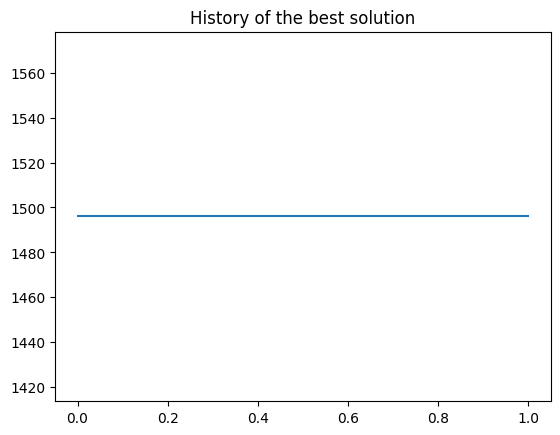

In [14]:
bga = BGA(objective, section_variable_ranges, length=8, nPop=10, minimize=True)

history = [objective(bga.best_phenotype())]

n_iter_bga = 2
bga.evolve(1)
n_iter_bga -= 1
fittness = bga.champion.fittness
tqdm.write(f"Initial fitness: {fittness:.4f}")
pbar = tqdm(total=n_iter_bga)
for epoch in range(n_iter_bga):
    bga.evolve(1)
    fittness = bga.champion.fittness
    history.append(fittness)
    pbar.set_description(
        f"Epoch {epoch+1}/{n_iter_bga} | "
        f"Fitness: {fittness:.4f}"
    )
    pbar.update(1)
pbar.close()

x = bga.champion.phenotype
fx = bga.champion.fittness
tqdm.write(f"✅ Optimization finished. Fitness: {fx:.4f}")

bga_solution = default_section_params.copy()
bga_solution.update({k: v for k, v in zip(section_variables, x)})

plt.plot(history)
plt.title('History of the best solution')
plt.show()

### Tighten with SciPy

In [17]:
from scipy.optimize import OptimizeResult, minimize as scipy_minimize
import warnings


def scipy_objective(x: Iterable[Number]) -> float:    
    return objective(x, penalty=1e12)


warnings.filterwarnings("ignore", message=".*Maximum number of function evaluations has been exceeded*")
scipy_opt_res: OptimizeResult = scipy_minimize(
    scipy_objective, 
    x0=bga.champion.phenotype, 
    method='Powell',
    bounds=section_variable_ranges,
    options={'maxiter': 1, 'maxfev': 1, 'disp': True}
)

scipy_solution = default_section_params.copy()
scipy_solution.update({k: v for k, v in zip(section_variables, scipy_opt_res.x)})

scipy_solution

         Current function value: 1495.982867
         Iterations: 0
         Function evaluations: 1


{'d': 169.33333333333334,
 'b': 126.50980392156863,
 't': 2.7058823529411766,
 'r_out': 15.388235294117646,
 'n_r': 4}

## Validate results

Check wether the final configuration is admissible.

In [18]:
solution = scipy_solution

In [19]:
section = construct_section(
    geometry_constructor=section_type,
    params=solution,
    material=config["material"],
    mesh_sizes=section_data["mesh_sizes"],
    calculate=True,
)

props = section_properties(section)
bending_stiffness = props["ixx"]

bernoulli_beam = NavierBeam(beam_length, number_of_modes, EI=bending_stiffness)
analysis_results = bernoulli_beam.linear_static_analysis(evaluation_points, beam_loads)
df = pd.concat([v.to_pandas()[["MZ", "SY"]] for v in analysis_results.values(deep=True)], ignore_index=True)
df.columns = ["mxx", "vy"]

utilization_max = -1.0
argmax = -1
for index, row in df.iterrows():
    loads = row.to_dict()
    stress = section.calculate_stress(**loads)
    material = section.materials[0]
    yield_strength = material.yield_strength
    utilizations = stress.get_stress()[0]["sig_vm"] / yield_strength
    utilization_max_ = utilizations.max()  # utilization(section, loads)
    if utilization_max_ > utilization_max:
        utilization_max = utilization_max_
        argmax = index

print(f"Maximum utilization of the optimized section: {utilization_max:.4f}")


Maximum utilization of the optimized section: 0.1923


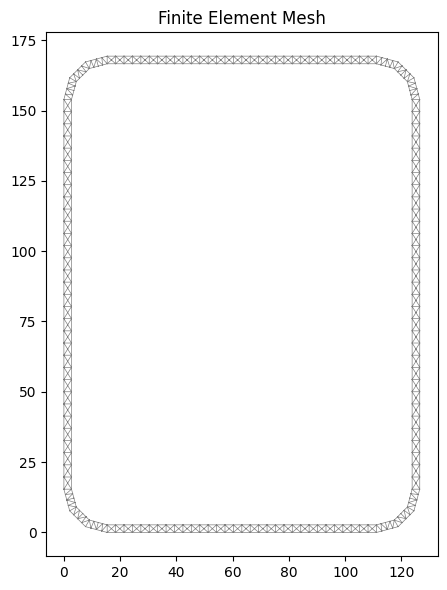

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
section.plot_mesh(ax=ax, materials=False)
plt.show()